# Proyecto Final · Bibliotecas públicas de Barcelona
## Notebook 03 — Análisis y visualización (Fase 3)

Cargamos la tabla maestra limpia (150 × 16) desde `data/processed` y respondemos a:
- **P0 (introducción):** ¿la oferta de libros explica la demanda?
- **PI1:** evolución del préstamo por distrito (índice base 2011).
- **PI2:** renta real ↔ préstamos per cápita (entre distritos, media 2015-2019).
- **PI3:** demografía ↔ préstamos per cápita.
- **Pivot a l'anàlisis de m2**

Estadística: Pearson + Spearman + IC bootstrap (sin p-valor). n=10, descriptivo.

In [43]:
# === SETUP: datos y utilidades ===
import pandas as pd, numpy as np, os
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
from pathlib import Path

PETROL="#16323D"; CORAL="#E07A5F"; TEAL="#2A9D8F"; GOLD="#E6A41E"; MUTED="#6B7B83"; INK="#1F2D34"
plt.rcParams.update({"font.size":12,"axes.edgecolor":MUTED,"axes.labelcolor":INK,
 "xtick.color":INK,"ytick.color":INK,"text.color":INK,"axes.spines.top":False,"axes.spines.right":False})

# carga robusta por nombre (encuentra los CSV estén en la subcarpeta que estén)
idx={f:os.path.join(b,f) for b,_,fs in os.walk(Path.cwd()) for f in fs if f.endswith(".csv")}
maestra=pd.read_csv(idx["maestra_distrito_anyo.csv"])
bib=pd.concat([pd.read_csv(idx["bibliotecas_xarxa_2010_2022_raw.csv"]),
               pd.read_csv(idx["bibliotecas_xarxa_2023_2024_raw.csv"])],ignore_index=True)
bib["Valor"]=pd.to_numeric(bib["Valor"],errors="coerce")
def spearman(x,y): return pd.Series(x).rank().corr(pd.Series(y).rank())  # Spearman sin scipy

assert maestra["Codi_Districte"].nunique()==10, "¡La maestra no tiene 10 distritos!"
print("OK ·", maestra.shape, "· 10 distritos")

OK · (150, 16) · 10 distritos


## P0 · ¿La oferta de libros explica la demanda?

Antes de estudiar la demanda conviene descartar lo obvio: ¿prestan más los distritos
con más fondo documental? El préstamo interbibliotecario hace que el catálogo sea de
**red** (oferta "líquida"): cualquiera puede pedir cualquier libro desde cualquier
biblioteca. Si el catálogo es común, el fondo *local* de un distrito no debería
diferenciar su demanda. Lo comprobamos.

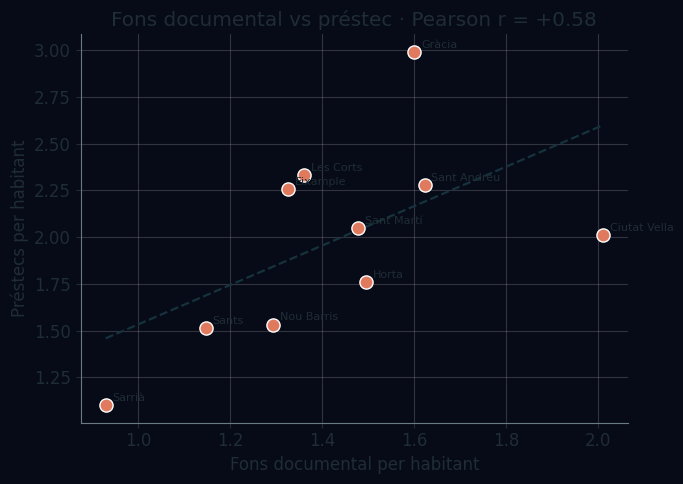

In [44]:
sub=maestra[maestra["Any"].between(2021,2024)].groupby("Nom_Districte").agg(
    fons=("oferta_per_capita","mean"), prest=("prestamos_per_capita","mean"))
r=sub["fons"].corr(sub["prest"])
fig,ax=plt.subplots(figsize=(7,5))
ax.scatter(sub["fons"],sub["prest"],s=90,color=CORAL,edgecolor="white",lw=1,zorder=3)
b,a=np.polyfit(sub["fons"],sub["prest"],1); xr=np.linspace(sub["fons"].min(),sub["fons"].max(),50)
ax.plot(xr,a+b*xr,color=PETROL,ls="--",lw=1.6)
for n,row in sub.iterrows():
    ax.annotate(n.split("-")[0],(row["fons"],row["prest"]),fontsize=8,xytext=(5,3),textcoords="offset points")
ax.set_xlabel("Fons documental per habitant"); ax.set_ylabel("Préstecs per habitant")
ax.set_title(f"Fons documental vs préstec · Pearson r = {r:+.2f}")
ax.grid(alpha=0.25); ax.set_axisbelow(True); fig.tight_layout(); plt.show()

La relación es **moderada y poco reveladora** (r ≈ +0,5): parece lógico que más fondo
acompañe más préstamo, pero la nube es dispersa. Lo dejamos como un indicio débil y
giramos el foco hacia la **demanda** (renta y demografía). *Spoiler:* esta correlación
no resistirá el test robusto más adelante —porque el catálogo, al ser de red, no es lo
que de verdad diferencia al territorio.

## PI1 · ¿Cómo ha evolucionado el préstamo?

Primero, el "qué está pasando": la evolución del préstamo presencial en la ciudad y
distrito a distrito, para ver si la caída es general o localizada.

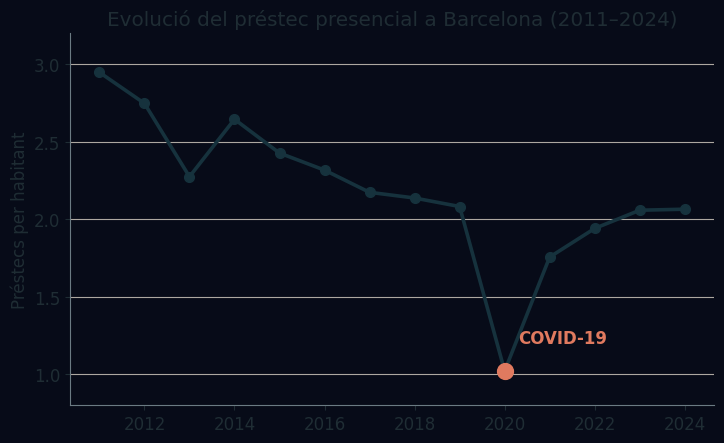

In [46]:
g=maestra.groupby("Any").agg(p=("prestamos_presenciales","sum"),pob=("poblacion","sum"))
g["pc"]=g["p"]/g["pob"]; g=g.loc[2011:2024]
fig,ax=plt.subplots(figsize=(7.4,4.6))
ax.plot(g.index,g["pc"],marker="o",color=PETROL,lw=2.6,ms=7,zorder=3)
ax.scatter([2020],[g.loc[2020,"pc"]],color=CORAL,s=130,zorder=4)
ax.annotate("COVID-19",(2020,g.loc[2020,"pc"]),color=CORAL,fontsize=12,fontweight="bold",xytext=(2020.3,1.2))
ax.set_ylabel("Préstecs per habitant"); ax.set_ylim(0.8,3.2)
ax.xaxis.set_major_locator(MultipleLocator(2))
ax.grid(axis="y",color="#D8D0C4",lw=0.8,alpha=0.8); ax.set_axisbelow(True)
ax.set_title("Evolució del préstec presencial a Barcelona (2011–2024)")
fig.tight_layout(); plt.show()

El préstamo por habitante cae de **~2,95 (2011) a ~2,08 (2019)** —un tercio menos— **antes
de la pandemia**. El 2020 se hunde a ~1 (COVID) y se recupera hasta ~2,07 en 2024, sin
superar la tendencia previa. El declive es **estructural**, no un bache puntual.

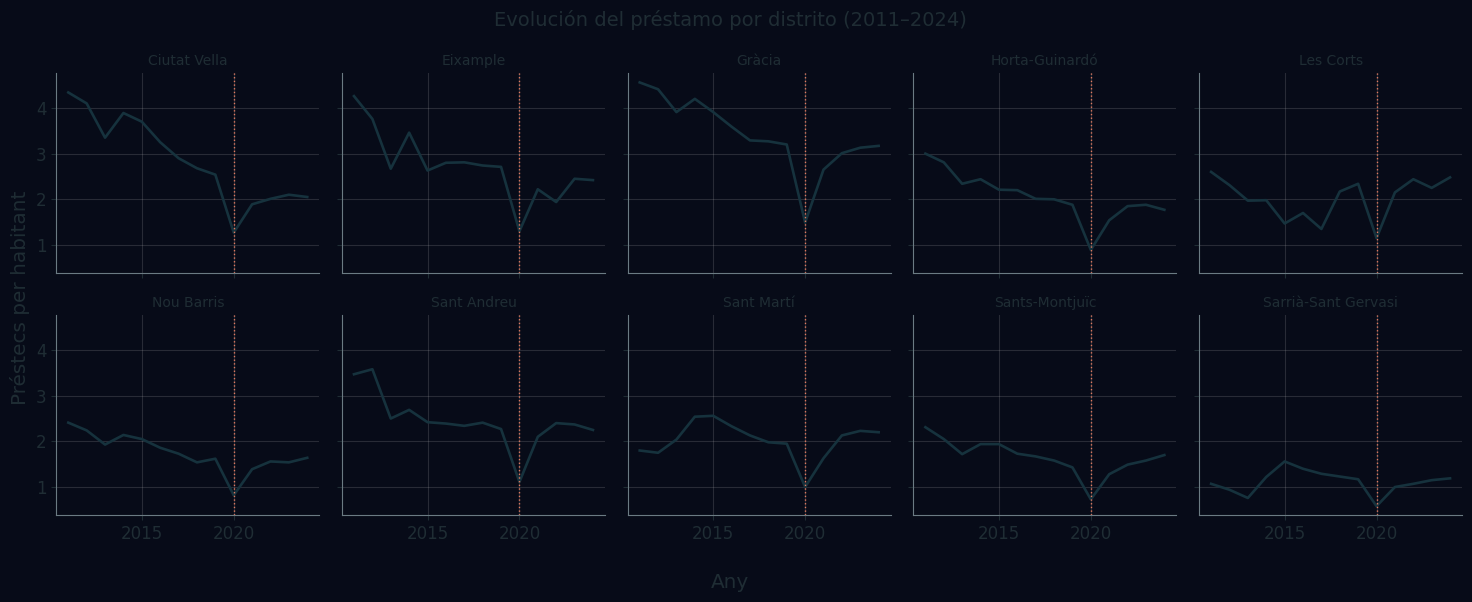

In [47]:
piv=maestra[maestra["Any"]>=2011].pivot(index="Any",columns="Nom_Districte",values="prestamos_per_capita")
fig,axes=plt.subplots(2,5,figsize=(15,6),sharex=True,sharey=True)
for ax,d in zip(axes.flat,piv.columns):
    ax.plot(piv.index,piv[d],color=PETROL,lw=1.9)
    ax.axvline(2020,color=CORAL,ls=":",lw=1)
    ax.set_title(d,fontsize=10); ax.grid(alpha=0.2); ax.set_axisbelow(True)
fig.suptitle("Evolución del préstamo por distrito (2011–2024)",fontsize=14)
fig.supxlabel("Any"); fig.supylabel("Préstecs per habitant")
fig.tight_layout(); plt.show()

Distrito a distrito el patrón se **repite**: declive sostenido + bache de 2020 en casi
todos. Pero ya se intuyen los **atípicos**: Sarrià-Sant Gervasi se mueve siempre por
debajo, y Ciutat Vella y Gràcia, muy arriba. Esas anomalías serán la pista del giro.

### ¿La caída es porque la gente se pasó al digital?

Una explicación tentadora: quizá no se lee menos, solo se lee en digital. Comparamos el
préstamo presencial con el virtual.

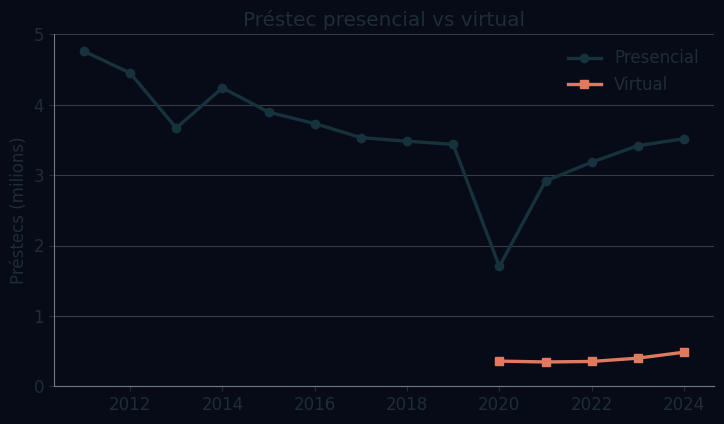

In [48]:
pres=maestra.groupby("Any")["prestamos_presenciales"].sum().loc[2011:2024]
vir=bib[bib["Indicador"]=="Prestecs_virtuals"].groupby("Any")["Valor"].sum()
fig,ax=plt.subplots(figsize=(7.4,4.4))
ax.plot(pres.index,pres.values/1e6,marker="o",color=PETROL,lw=2.4,ms=6,label="Presencial")
ax.plot(vir.index,vir.values/1e6,marker="s",color=CORAL,lw=2.4,ms=6,label="Virtual")
ax.set_ylabel("Préstecs (milions)"); ax.set_ylim(0,5)
ax.xaxis.set_major_locator(MultipleLocator(2))
ax.legend(frameon=False); ax.grid(axis="y",alpha=0.3); ax.set_axisbelow(True)
ax.set_title("Préstec presencial vs virtual")
fig.tight_layout(); plt.show()

No cuadra: el préstamo **virtual** solo existe desde 2020 y es **~10× menor** (0,48 M
frente a 3,52 M de presencial en 2024). El digital no se ha "comido" el papel —el declive
es anterior y mucho más profundo.

### ¿La caída es porque hay menos bibliotecas?

La otra explicación fácil: quizá la red se ha reducido. Veámoslo poniendo en el mismo
índice (2011 = 100) el número de bibliotecas y el préstamo.

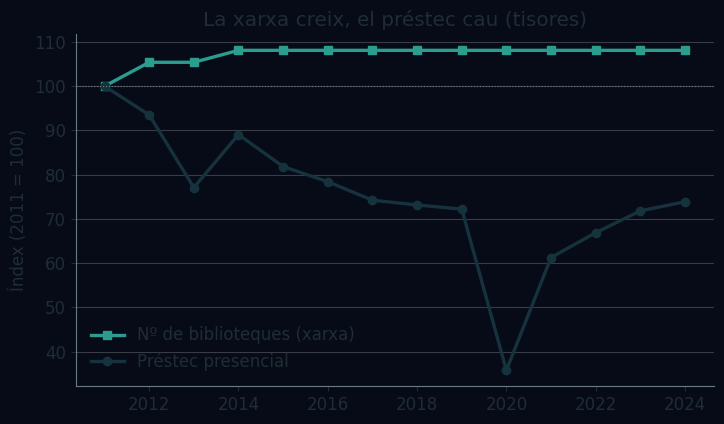

In [49]:
nbib=(bib.dropna(subset=["Nom_Equipament"]).groupby("Any")["Nom_Equipament"].nunique()
      .reindex(range(2011,2025)).ffill())          # 2020 ve sense noms -> s'omple amb el valor previ
prest=maestra.groupby("Any")["prestamos_presenciales"].sum().loc[2011:2024]
idxn=100*nbib/nbib.loc[2011]; idxp=100*prest/prest.loc[2011]
fig,ax=plt.subplots(figsize=(7.4,4.4))
ax.plot(idxn.index,idxn.values,marker="s",color=TEAL,lw=2.4,ms=6,label="Nº de biblioteques (xarxa)")
ax.plot(idxp.index,idxp.values,marker="o",color=PETROL,lw=2.4,ms=6,label="Préstec presencial")
ax.axhline(100,color=MUTED,ls=":",lw=0.8); ax.set_ylabel("Índex (2011 = 100)")
ax.xaxis.set_major_locator(MultipleLocator(2))
ax.legend(frameon=False,loc="lower left"); ax.grid(axis="y",alpha=0.3); ax.set_axisbelow(True)
ax.set_title("La xarxa creix, el préstec cau (tisores)")
fig.tight_layout(); plt.show()

Tampoco: es lo contrario. Mientras el préstamo caía, la red **creció** (de 37 a 40
bibliotecas) — las dos líneas dibujan unas **tijeras**. La caída **no es un problema de
oferta de equipamientos**. (Pista que reaparecerá: lo que importará no será *cuántas*
bibliotecas hay, sino *cuánto espacio* tienen.)

## PI2 · ¿La renta explica el préstamo?

La hipótesis intuitiva: los distritos con más renta leen más. Relacionamos la renta real
(deflactada a 2019) con el préstamo por habitante, sobre el panel distrito-año, y medimos
con Pearson + Spearman e intervalo de confianza por *bootstrap* de conglomerados.

Pearson -0.22 · Spearman -0.08 · IC95% [-0.67, +0.63]


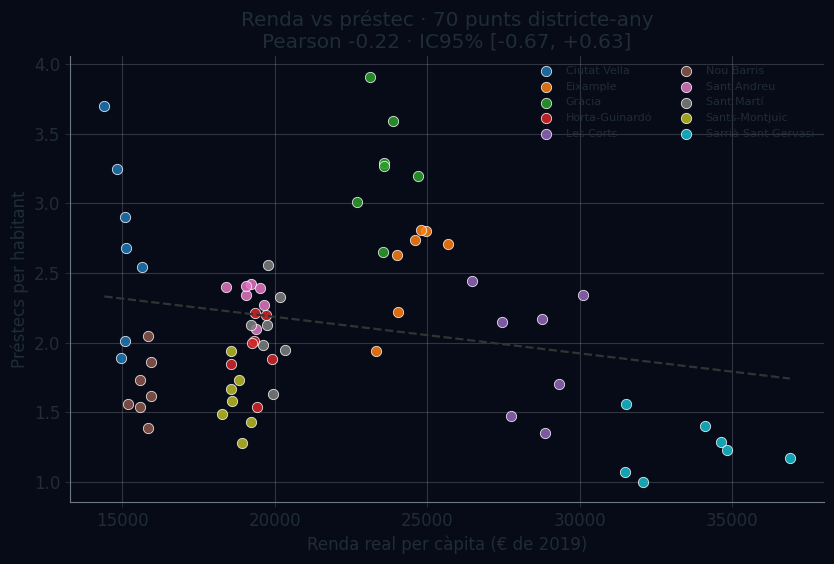

In [50]:
panel=maestra[(maestra["Any"].between(2015,2022))&(maestra["Any"]!=2020)].dropna(
    subset=["renta_real","prestamos_per_capita"]).copy()
assert panel["Codi_Districte"].nunique()==10, "¡Faltan distritos en el panel!"

def cluster_boot(p,xc,yc="prestamos_per_capita",n=3000,seed=0):
    rng=np.random.default_rng(seed); ds=p["Codi_Districte"].unique()
    g={d:p[p["Codi_Districte"]==d] for d in ds}; rs=[]
    for _ in range(n):
        m=pd.concat([g[d] for d in rng.choice(ds,len(ds),replace=True)]); r=m[xc].corr(m[yc])
        if pd.notna(r): rs.append(r)
    return np.percentile(rs,[2.5,97.5])

rp=panel["renta_real"].corr(panel["prestamos_per_capita"]); rsp=spearman(panel["renta_real"],panel["prestamos_per_capita"])
lo,hi=cluster_boot(panel,"renta_real")
print(f"Pearson {rp:+.2f} · Spearman {rsp:+.2f} · IC95% [{lo:+.2f}, {hi:+.2f}]")

dists=sorted(panel["Nom_Districte"].unique()); colors=dict(zip(dists,plt.cm.tab10(np.linspace(0,1,10))))
fig,ax=plt.subplots(figsize=(8.5,5.8))
for d in dists:
    s=panel[panel["Nom_Districte"]==d]
    ax.scatter(s["renta_real"],s["prestamos_per_capita"],color=colors[d],s=55,alpha=0.85,edgecolor="white",lw=0.6,label=d)
b,a=np.polyfit(panel["renta_real"],panel["prestamos_per_capita"],1); xr=np.linspace(panel["renta_real"].min(),panel["renta_real"].max(),50)
ax.plot(xr,a+b*xr,color="#333",ls="--",lw=1.6)
ax.set_xlabel("Renda real per càpita (€ de 2019)"); ax.set_ylabel("Préstecs per habitant")
ax.set_title(f"Renda vs préstec · {len(panel)} punts districte-any\nPearson {rp:+.2f} · IC95% [{lo:+.2f}, {hi:+.2f}]")
ax.legend(fontsize=8,ncol=2,frameon=False); ax.grid(alpha=0.25); ax.set_axisbelow(True); fig.tight_layout(); plt.show()

**No hay relación fiable** (Pearson −0,22; el IC [−0,67, +0,63] cruza el cero). Si acaso,
la nube apunta ligeramente al revés: el distrito más rico (Sarrià) presta poco, y uno de
los más humildes (Ciutat Vella), mucho. La renta **no** explica el préstamo.

## PI3 · ¿La demografía explica el préstamo?

Repetimos el análisis con la edad (% gente mayor, % joven) y el origen (% extranjera),
mismo método robusto.

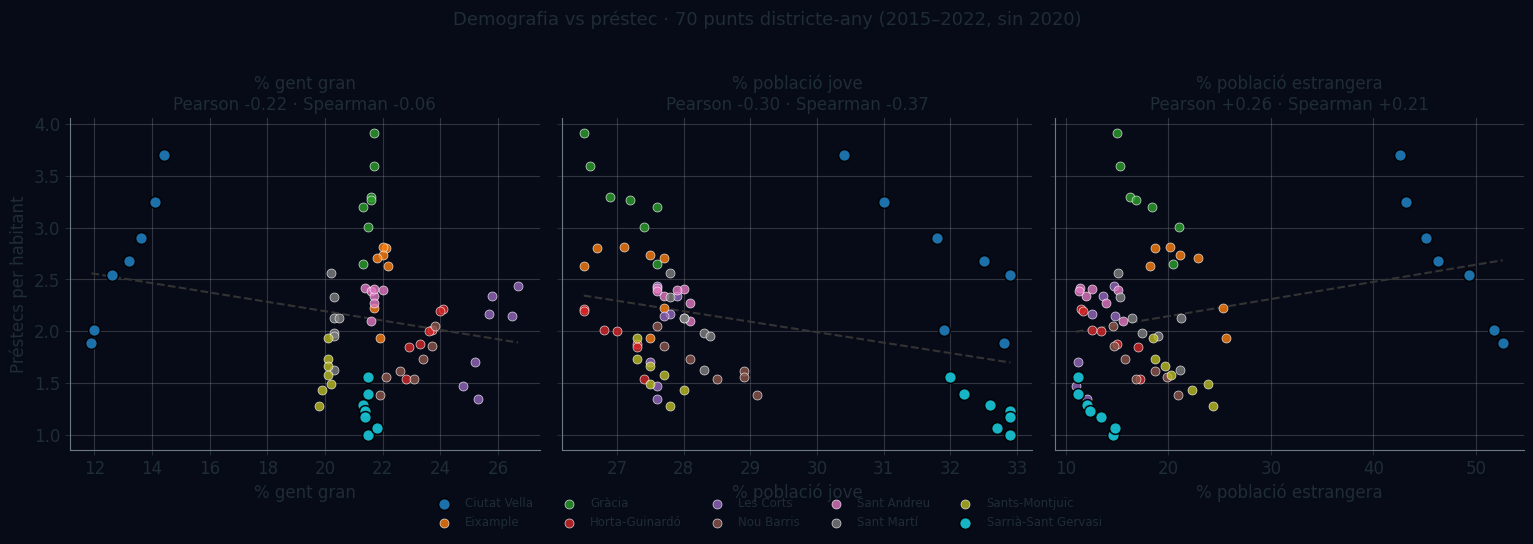

In [51]:
panel=maestra[(maestra["Any"].between(2015,2022))&(maestra["Any"]!=2020)].dropna(
    subset=["pct_mayores","pct_joven","pct_extranjera","prestamos_per_capita"]).copy()
demos=[("pct_mayores","% gent gran"),("pct_joven","% població jove"),("pct_extranjera","% població estrangera")]
dists=sorted(panel["Nom_Districte"].unique()); colors=dict(zip(dists,plt.cm.tab10(np.linspace(0,1,10))))
fig,axes=plt.subplots(1,3,figsize=(15.5,5),sharey=True)
for ax,(col,lbl) in zip(axes,demos):
    for d in dists:
        s=panel[panel["Nom_Districte"]==d]; big=d in ("Ciutat Vella","Sarrià-Sant Gervasi")
        ax.scatter(s[col],s["prestamos_per_capita"],color=colors[d],s=72 if big else 42,
                   alpha=0.95 if big else 0.8,edgecolor="black" if big else "white",
                   lw=1.1 if big else 0.5,zorder=4 if big else 3,label=d)
    b,a=np.polyfit(panel[col],panel["prestamos_per_capita"],1); xr=np.linspace(panel[col].min(),panel[col].max(),50)
    ax.plot(xr,a+b*xr,color="#333",ls="--",lw=1.5)
    ax.set_title(f"{lbl}\nPearson {panel[col].corr(panel['prestamos_per_capita']):+.2f} · "
                 f"Spearman {spearman(panel[col],panel['prestamos_per_capita']):+.2f}",fontsize=12)
    ax.set_xlabel(lbl); ax.grid(alpha=0.25); ax.set_axisbelow(True)
axes[0].set_ylabel("Préstecs per habitant")
h,l=axes[0].get_legend_handles_labels(); fig.legend(h,l,loc="lower center",ncol=5,frameon=False,fontsize=8.5,bbox_to_anchor=(0.5,-0.04))
fig.suptitle("Demografia vs préstec · 70 punts districte-any (2015–2022, sin 2020)",y=1.02,fontsize=13)
fig.tight_layout(); plt.show()

Tampoco: ni edad ni origen (todos los IC cruzan el cero). El único indicio positivo es
**% estrangera (+0,26)**, pero lo dibuja **un solo distrito, Ciutat Vella** (arriba-derecha,
resaltado): mucha inmigración *y* mucho préstamo. No es la población —sería contradictorio
por la barrera del idioma—, es que Ciutat Vella, **muy céntrico, capta lectores de toda la
ciudad** (efecto captación). Esta anomalía nos hizo dejar de mirar las medias y empezar a
mirar los **valores atípicos**.

# PIVOTE · ¿Y si lo que mueve el préstamo es el ESPACIO?

Ni la renta ni la demografía explican el préstamo. En lugar de cerrar con un "no hay
relación", volvimos a los distritos atípicos. El más desconcertante: **Sarrià-Sant
Gervasi**, el más rico y el que menos presta. ¿Qué le hace diferente?

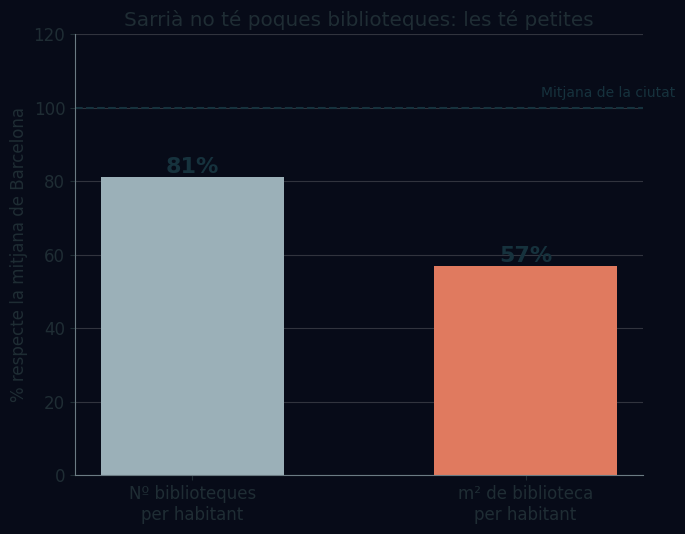

In [54]:
YM=[2021,2022,2023,2024]
m2=(bib[(bib["Indicador"]=="Metres_Quadrats")&(bib["Any"].isin(YM))]
    .groupby(["Nom_Districte","Any"])["Valor"].sum().groupby("Nom_Districte").mean())
nb=(bib[(bib["Indicador"]=="Metres_Quadrats")&(bib["Any"].isin(YM))]
    .groupby(["Nom_Districte","Any"]).size().groupby("Nom_Districte").mean())
pob=maestra[maestra["Any"].isin(YM)].groupby("Nom_Districte")["poblacion"].mean()
comp=pd.DataFrame({"biblio_100k":1e5*nb/pob,"m2_1000hab":1000*m2/pob})
pct=comp.loc["Sarrià-Sant Gervasi"]/comp.mean()*100
fig,ax=plt.subplots(figsize=(7,5.5))
bars=ax.bar(["Nº biblioteques\nper habitant","m² de biblioteca\nper habitant"],
            [pct["biblio_100k"],pct["m2_1000hab"]],color=["#9BB0B8",CORAL],width=0.55)
ax.axhline(100,color=PETROL,lw=1.5,ls="--"); ax.text(1.45,103,"Mitjana de la ciutat",color=PETROL,fontsize=10,ha="right")
for bb,p in zip(bars,[pct["biblio_100k"],pct["m2_1000hab"]]):
    ax.annotate(f"{p:.0f}%",(bb.get_x()+bb.get_width()/2,p),ha="center",va="bottom",fontsize=16,fontweight="bold",color=PETROL)
ax.set_ylabel("% respecte la mitjana de Barcelona"); ax.set_ylim(0,120)
ax.set_title("Sarrià no té poques biblioteques: les té petites")
ax.grid(axis="y",alpha=0.25); ax.set_axisbelow(True); fig.tight_layout(); plt.show()

Sarrià tiene un nº de bibliotecas casi normal (**~81%** de la media) pero **la mitad de m²
por habitante (~57%)**: no le faltan bibliotecas, **las tiene pequeñas**. Primera intuición:
quizá lo que mueve el préstamo no es quién eres, sino **cuánto espacio** de biblioteca tienes.

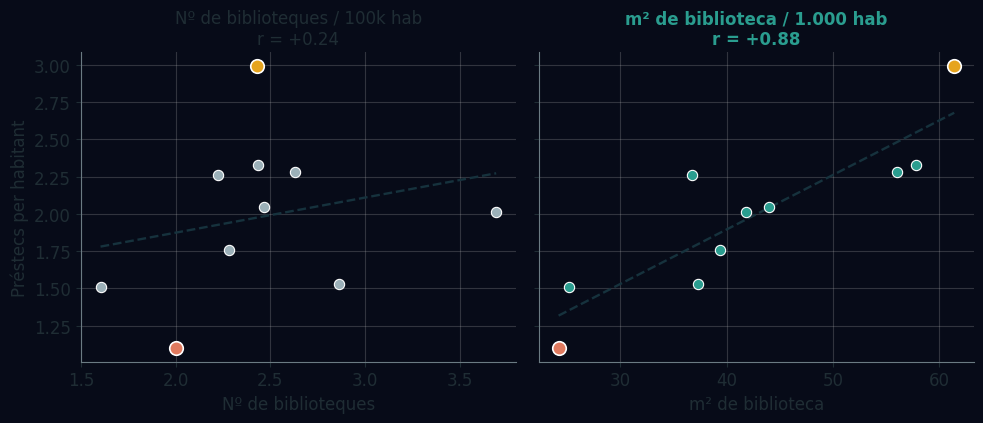

In [55]:
YM=[2021,2022,2023,2024]
m2=(bib[(bib["Indicador"]=="Metres_Quadrats")&(bib["Any"].isin(YM))]
    .groupby(["Nom_Districte","Any"])["Valor"].sum().groupby("Nom_Districte").mean())
nb=(bib[(bib["Indicador"]=="Metres_Quadrats")&(bib["Any"].isin(YM))]
    .groupby(["Nom_Districte","Any"]).size().groupby("Nom_Districte").mean())
bb=maestra[maestra["Any"].isin(YM)].groupby("Nom_Districte").agg(pob=("poblacion","mean"),prest=("prestamos_per_capita","mean"))
bb["biblio_100k"]=1e5*nb/bb["pob"]; bb["m2_1000"]=1000*m2/bb["pob"]
fig,axes=plt.subplots(1,2,figsize=(10,4.4),sharey=True)
for ax,(col,lbl,c,win) in zip(axes,[("biblio_100k","Nº de biblioteques / 100k hab","#9BB0B8",False),
                                     ("m2_1000","m² de biblioteca / 1.000 hab",TEAL,True)]):
    r=bb[col].corr(bb["prest"]); ax.scatter(bb[col],bb["prest"],s=55,color=c,edgecolor="white",lw=0.8,zorder=3)
    for nm,cc in [("Sarrià-Sant Gervasi",CORAL),("Gràcia",GOLD)]:
        ax.scatter(bb.loc[nm,col],bb.loc[nm,"prest"],s=95,color=cc,edgecolor="white",lw=1.2,zorder=4)
    b,a=np.polyfit(bb[col],bb["prest"],1); xr=np.linspace(bb[col].min(),bb[col].max(),50); ax.plot(xr,a+b*xr,color=PETROL,ls="--",lw=1.7)
    ax.set_title(f"{lbl}\nr = {r:+.2f}",fontsize=12,fontweight="bold" if win else "normal",color=TEAL if win else INK)
    ax.set_xlabel(lbl.split(" / ")[0]); ax.grid(alpha=0.25); ax.set_axisbelow(True)
axes[0].set_ylabel("Préstecs per habitant"); fig.tight_layout(); plt.show()

La prueba a escala de ciudad: el **nº de bibliotecas** apenas correlaciona (**+0,24**, nube
dispersa), pero los **m²/habitante** sí, y mucho (**+0,88**, recta clara). No es *cuántas*
puertas hay, es *cuánto espacio*. Sarrià (coral) y Gràcia (oro) solo se alinean en el panel
del m².

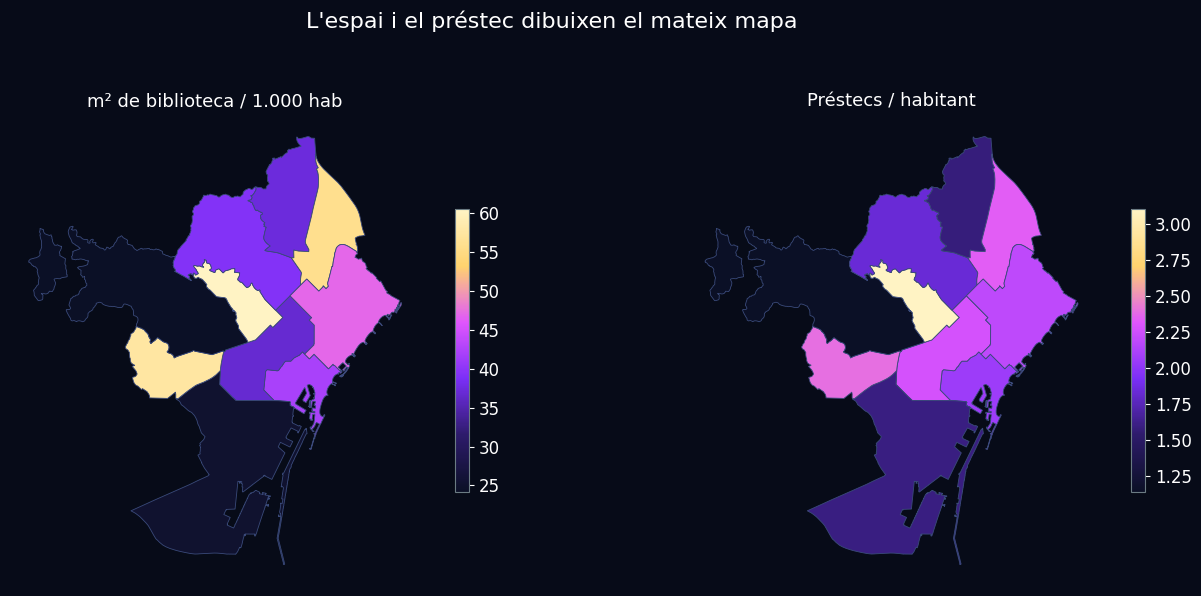

In [56]:
import geopandas as gpd, matplotlib.colors as mcolors, unicodedata
URL="https://raw.githubusercontent.com/martgnz/bcn-geodata/master/districtes/districtes.geojson"
geo=gpd.read_file(URL); NAMECOL="NOM"   # comprueba con print(geo.columns) si hiciera falta
YM=[2022,2023,2024]
m2=(bib[(bib["Indicador"]=="Metres_Quadrats")&(bib["Any"].isin(YM))]
    .groupby(["Nom_Districte","Any"])["Valor"].sum().groupby("Nom_Districte").mean())
base=maestra[maestra["Any"].isin(YM)].groupby("Nom_Districte").agg(pob=("poblacion","mean"),prest=("prestamos_per_capita","mean"))
vals=pd.DataFrame({"m2":1000*m2/base["pob"],"prest":base["prest"]})
def norm(s): return unicodedata.normalize("NFKD",str(s)).encode("ascii","ignore").decode().lower().strip()
vn={norm(k):v for k,v in vals["m2"].items()}; pn={norm(k):v for k,v in vals["prest"].items()}
geo["m2"]=geo[NAMECOL].map(lambda x:vn.get(norm(x))); geo["prest"]=geo[NAMECOL].map(lambda x:pn.get(norm(x)))
galaxy=mcolors.LinearSegmentedColormap.from_list("g",["#0b1026","#2d1b6b","#7b2ff7","#e056fd","#ffd36e","#fff3c4"])
BG="#070b18"
fig,axes=plt.subplots(1,2,figsize=(14,6),facecolor=BG)
for ax,(col,t) in zip(axes,[("m2","m² de biblioteca / 1.000 hab"),("prest","Préstecs / habitant")]):
    ax.set_facecolor(BG); geo.plot(column=col,cmap=galaxy,linewidth=0.6,edgecolor="#3a4a7a",legend=True,ax=ax,legend_kwds={"shrink":0.6})
    ax.set_title(t,color="white",fontsize=13); ax.axis("off")
for cax in fig.axes:
    cax.tick_params(colors="white"); [t.set_color("white") for t in cax.get_yticklabels()]
fig.suptitle("L'espai i el préstec dibuixen el mateix mapa",color="white",fontsize=16,y=0.99)
fig.tight_layout(rect=[0,0,1,0.94]); fig.savefig("mapa_m2_vs_prestec.png",dpi=170,facecolor=BG,bbox_inches="tight"); plt.show()

Los dos mapas comparten patrón espacial: donde hay m², hay préstamo. La excepción es
**Ciutat Vella**, que brilla más en préstamo que en m² → el efecto captación, visible sobre
el mapa. Conclusión: ni renta, ni demografía, ni catálogo —**el espacio físico** es lo que
mueve el préstamo.

## Síntesis y conclusiones

Empezamos asumiendo que la lectura de un distrito dependería de su **demanda** —renta y
demografía— y que la oferta era constante (oferta "líquida": el préstamo interbibliotecario
hace que el catálogo sea de toda la red). El análisis fue desmontando esa hipótesis:

- **PI1** — El préstamo cae ~⅓ desde 2011, *antes* de la pandemia. No es por cierres
  (la red creció de 37 a 40) ni por el digital (10× menor y solo desde 2020).
- **PI2 / PI3** — Ni la renta (r = −0,22) ni la demografía mantienen relación fiable:
  todos los intervalos de confianza cruzan el cero.
- **El giro** — Las anomalías (Sarrià, Ciutat Vella) no eran ruido, sino la pista. Al
  mirar la infraestructura, apareció el factor que sí explica el préstamo.

**Hallazgo central:** los **m² de biblioteca por habitante** son el único factor que supera
el test robusto (r = +0,88; IC95% [+0,56, +0,94]), por encima de la renta, la demografía,
el catálogo (fons) y el número de bibliotecas. El catálogo es líquido y se comparte por la
red; lo que queda **anclado al territorio** es el espacio físico. No es *cuántas* bibliotecas
hay, sino *cuánto espacio* tienen.

**Aportación para la decisión:** a diferencia de la renta o la demografía —que no se cambian
por decreto—, los m² son una palanca de gestión pública. **Invertir en espacio de biblioteca
es invertir en hábito lector**, con una clara lectura de equidad. Sarrià-Sant Gervasi es la
mayor oportunidad de mejora.

**Limitaciones:** relación observacional (no causal en sentido estricto, aunque la oferta de
m² es exógena); efecto captación en distritos céntricos (Ciutat Vella); m² disponibles solo
desde 2020; análisis ecológico sobre 10 distritos. La caída estructural del ~30% no se
explica por los m² (casi constantes) ni por el digital, y queda como pregunta abierta.

> *Las bibliotecas, por el solo hecho de ocupar espacio, curvan la demanda a su alrededor
> —como la gravedad curva el espacio-tiempo.*